In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from pprint import pformat

from hloc import (
    extract_features,
    match_features,
    match_dense,
    pairs_from_covisibility,
    pairs_from_retrieval,
)
from hloc import colmap_from_nvm, triangulation, localize_sfm, visualization
import numpy as np
import pandas as pd
from pipeline_utils import read_images_text, colmap_dict_to_pose
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Pipeline for UCF 3259 visual localization

In [3]:
dataset = Path("datasets/3259_combined/")  # change this if your dataset is somewhere else
images = dataset / "video_frames/"
outputs = Path("outputs/3259_combined/")  # where everything will be saved

# list the standard configurations available
print(f"Configs for feature extractors:\n{pformat(extract_features.confs)}")
print(f"Configs for feature matchers:\n{pformat(match_features.confs)}")
print(f"Configs for feature matchers:\n{pformat(match_dense.confs)}")

Configs for feature extractors:
{'aliked-n16': {'model': {'model_name': 'aliked-n16', 'name': 'aliked'},
                'output': 'feats-aliked-n16',
                'preprocessing': {'grayscale': False, 'resize_max': 1024}},
 'd2net-ss': {'model': {'multiscale': False, 'name': 'd2net'},
              'output': 'feats-d2net-ss',
              'preprocessing': {'grayscale': False, 'resize_max': 1600}},
 'dir': {'model': {'name': 'dir'},
         'output': 'global-feats-dir',
         'preprocessing': {'resize_max': 1024}},
 'disk': {'model': {'max_keypoints': 5000, 'name': 'disk'},
          'output': 'feats-disk',
          'preprocessing': {'grayscale': False, 'resize_max': 1600}},
 'eigenplaces': {'model': {'name': 'eigenplaces'},
                 'output': 'global-feats-eigenplaces',
                 'preprocessing': {'resize_max': 1024}},
 'netvlad': {'model': {'name': 'netvlad'},
             'output': 'global-feats-netvlad',
             'preprocessing': {'resize_max': 1024}},
 

In [4]:
# pick one of the configurations for image retrieval, local feature extraction, and matching
retrieval_conf = extract_features.confs["netvlad"]

feature_conf = extract_features.confs["sift"]
matcher_conf = match_features.confs["NN-ratio"]
#matcher_conf = match_dense.confs['loftr']

reference_sfm = outputs / "sfm_disk2+NN"  # the SfM model we will build

## Extract local features for database

In [ ]:
# NOT FOR LOFTR
if matcher_conf["model"]["name"] != "loftr":
    features = extract_features.main(feature_conf, images, outputs)

[2026/08/27 18:11:44 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'dog'},
 'output': 'feats-sift',
 'preprocessing': {'grayscale': True, 'resize_max': 1600}}
[2026/08/27 18:11:44 hloc INFO] Found 1915 images in root datasets/3259_combined/video_frames.
[2026/08/27 18:11:46 hloc INFO] Skipping the extraction.


The function returns the path of the file in which all the extracted features are stored.

## Generate pairs for the SfM reconstruction
Instead of matching all database images exhaustively, we exploit the existing SIFT model to find which image pairs are the most covisible. We do a covisiblity search, selecting the top 20 most covisibile neighbors for each image.

In [6]:
sfm_pairs = outputs / "pairs-db-covis20.txt"  # top 20 most covisible in SIFT model
pairs_from_covisibility.main(outputs / "sfm_sift", sfm_pairs, num_matched=20)

[2026/08/27 18:11:49 hloc INFO] Reading the COLMAP model...
[2026/08/27 18:11:52 hloc INFO] Extracting image pairs from covisibility info...
100%|██████████| 1914/1914 [00:08<00:00, 216.64it/s]
[2026/08/27 18:12:01 hloc INFO] Found 38237 pairs.


## Match the database images

In [7]:
if matcher_conf["model"]["name"] != "loftr":
    sfm_matches = match_features.main(
        matcher_conf, sfm_pairs, feature_conf["output"], outputs
    )

[2026/08/27 18:12:03 hloc INFO] Matching local features with configuration:
{'model': {'do_mutual_check': True,
           'name': 'nearest_neighbor',
           'ratio_threshold': 0.8},
 'output': 'matches-NN-mutual-ratio.8'}
[2026/08/27 18:12:04 hloc INFO] Skipping the matching.


In [ ]:
# LOFTR
if matcher_conf["model"]["name"] == "loftr":
    features, sfm_matches = match_dense.main(
            matcher_conf, sfm_pairs, images, outputs, max_kps=8192, overwrite=False
        )

## Triangulate a new SfM model from the given poses
We triangulate the sparse 3D pointcloud given the matches and the reference poses stored in the SIFT COLMAP model.

In [8]:
reconstruction = triangulation.main(
    reference_sfm, outputs / "sfm_sift", images, sfm_pairs, features, sfm_matches
)

[2026/08/27 18:12:08 hloc WARNING] The database already exists, deleting it.
[2026/08/27 18:12:08 hloc INFO] Importing features into the database...
100%|██████████| 1914/1914 [00:02<00:00, 855.17it/s]
[2026/08/27 18:12:10 hloc INFO] Importing matches into the database...
100%|██████████| 38237/38237 [00:25<00:00, 1474.29it/s]
[2026/08/27 18:12:36 hloc INFO] Performing geometric verification of the matches...
100%|██████████| 1914/1914 [01:44<00:00, 18.34it/s]
[2026/08/27 18:14:21 hloc INFO] mean/med/min/max valid matches 82.36/86.67/0.00/100.00%.
[2026/08/27 18:14:21 hloc INFO] Running 3D triangulation...
I20260827 18:14:21.360934 134112938583872 incremental_pipeline.cc:237] Loading database
I20260827 18:14:21.361983 134112938583872 database_cache.cc:66] Loading cameras...
I20260827 18:14:21.362021 134112938583872 database_cache.cc:76]  2 in 0.000s
I20260827 18:14:21.362037 134112938583872 database_cache.cc:84] Loading matches...
I20260827 18:14:21.401089 134112938583872 database_cach

## Find image pairs via image retrieval
We extract global descriptors with NetVLAD and find for each image the $k$ most similar ones. A larger $k$ improves the robustness of the localization for difficult queries but makes the matching more expensive. Using $k{=}10{-}20$ is generally a good tradeoff.

In [9]:
global_descriptors = extract_features.main(retrieval_conf, images, outputs)

[2026/08/27 18:15:51 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'netvlad'},
 'output': 'global-feats-netvlad',
 'preprocessing': {'resize_max': 1024}}
[2026/08/27 18:15:51 hloc INFO] Found 1915 images in root datasets/3259_combined/video_frames.
100%|██████████| 529M/529M [00:59<00:00, 9.39MB/s] 



HHHHHHHHHHH /home/skedia/.cache/torch/hub/netvlad/VGG16-NetVLAD-Pitts30K.mat


100%|██████████| 1271/1271 [01:27<00:00, 14.53it/s]
[2026/08/27 18:18:29 hloc INFO] Finished exporting features.


# Query Images

In [10]:
num_retrival=20
retrival = "netvlad"
query_set = 0
retrieval_conf = extract_features.confs[retrival]

query_images = dataset / f"query_{query_set}"
outputs_query = outputs / f"query_{query_set}"
loc_pairs = outputs / f"pairs-query_{query_set}-{retrival}{num_retrival}.txt"
global_descriptors = outputs / f"global-feats-{retrival}.h5"
query_descriptors = outputs_query / f"global-feats-{retrival}.h5"


In [ ]:
# Superpoint+SuperGlue
# feature_conf = extract_features.confs["superpoint_inloc"]
# matcher_conf = match_features.confs["superglue"]
# matcher_name = matcher_conf["output"]

# reconstruction = outputs / "sfm_superpoint+superglue"
# features = outputs / "feats-superpoint-n4096-r1600.h5"
# inlier_threshold = 32

# results = outputs / f"3259_hloc_query{query_set}_disk+{matcher_name}_{retrival}{num_retrival}.txt"  # the result file
### 0: 129/130 (+2 errors)  ,1: 138/143 ,2:125/127

In [ ]:
# Superpoint+SuperGlue_indoor
# feature_conf = extract_features.confs["superpoint_inloc"]
# matcher_conf = match_features.confs["superglue_indoor"]
# matcher_name = matcher_conf["output"]

# reconstruction = outputs / "sfm_superpoint+superglue_indoor"
# features = outputs / "feats-superpoint-n4096-r1600.h5"
# inlier_threshold = 32

# results = outputs / f"3259_hloc_query{query_set}_disk+{matcher_name}_{retrival}{num_retrival}.txt"  # the result file
### 0: 127 / 130  ,   1: 137/143   ,  2: 123/127

In [ ]:
# Superpoint+NN
# feature_conf = extract_features.confs["superpoint_inloc"]
# matcher_conf = match_features.confs["NN-superpoint"]
# matcher_name = matcher_conf["output"]

# reconstruction = outputs / "sfm_superpoint+NN"
# features = outputs / "feats-superpoint-n4096-r1600.h5"
# inlier_threshold = 32

# results = outputs / f"3259_hloc_query{query_set}_superpoint+{matcher_name}_{retrival}{num_retrival}.txt"  # the result file
### 0: 125/130  ,1: 134/143 ,2:119/127

In [11]:
# Sift+NN
feature_conf = extract_features.confs["sift"]
matcher_conf = match_features.confs["NN-ratio"]
matcher_name = matcher_conf["output"]

reconstruction = outputs / "sfm_sift+NN"
features = outputs / "feats-sift.h5"
inlier_threshold = 10

results = outputs / f"3259_hloc_query{query_set}_sift+{matcher_name}_{retrival}{num_retrival}.txt"  # the result file
### 0: 127/130  ,1: 134/143  ,2: 120/127

In [ ]:
# DISK+LightGlue
# feature_conf = extract_features.confs["disk"]
# matcher_conf = match_features.confs["disk+lightglue"]
# matcher_name = matcher_conf["output"]

# reconstruction = outputs / "sfm_disk+lightglue"
# features = outputs / "feats-disk.h5"
# inlier_threshold = 40

# results = outputs / f"3259_hloc_query{query_set}_disk+{matcher_name}_{retrival}{num_retrival}.txt"  # the result file
### 0: 129/130 (+2 errors)   ,  1: 140/143 (+4 errors)   ,2:  124 / 127

In [ ]:
# DISK2+NN
# feature_conf = extract_features.confs["disk2"]
# matcher_conf = match_features.confs["NN-ratio"]
# matcher_name = matcher_conf["output"]

# reconstruction = outputs / "sfm_disk2+NN"
# features = outputs / "feats-disk2.h5"
# inlier_threshold = 10

# results = outputs / f"3259_hloc_query{query_set}_disk+{matcher_name}_{retrival}{num_retrival}.txt"  # the result file
### 0: 125/130  ,1: 130/143 ,2: 116/127

In [ ]:
# LOFTR
# matcher_conf = match_dense.confs['loftr']
# matcher_name = matcher_conf["output"]

# reconstruction = outputs / "sfm_loftr"
# features = outputs / f"feats_{matcher_name}.h5"
# inlier_threshold = 100

# query_matches = outputs_query / f"matches-loftr_{loc_pairs.stem}.h5"
# results = outputs / f"3259_hloc_loftr_{retrival}{num_retrival}.txt"
### 0: 128/130 (+2 errors)   ,  1: 137/143    ,2:  123/127

## Feature extraction Query

In [12]:
# NOT FOR LOFTR
if matcher_conf["model"]["name"] != "loftr":
    features_query = extract_features.main(feature_conf, query_images, outputs_query)
    print(features_query)

[2026/08/27 18:18:43 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'dog'},
 'output': 'feats-sift',
 'preprocessing': {'grayscale': True, 'resize_max': 1600}}
[2026/08/27 18:18:43 hloc INFO] Found 130 images in root datasets/3259_combined/query_0.
[2026/08/27 18:18:44 hloc INFO] Skipping the extraction.


outputs/3259_combined/query_0/feats-sift.h5


In [13]:
query_descriptors = extract_features.main(retrieval_conf, query_images, outputs_query)
print(query_descriptors)

[2026/08/27 18:18:47 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'netvlad'},
 'output': 'global-feats-netvlad',
 'preprocessing': {'resize_max': 1024}}
[2026/08/27 18:18:47 hloc INFO] Found 130 images in root datasets/3259_combined/query_0.
[2026/08/27 18:18:47 hloc INFO] Skipping the extraction.


outputs/3259_combined/query_0/global-feats-netvlad.h5


In [14]:
pairs_from_retrieval.main(
    query_descriptors, loc_pairs, num_matched=num_retrival, db_prefix=None,
    query_prefix=None, db_descriptors=global_descriptors
)

[2026/08/27 18:18:49 hloc INFO] Extracting image pairs from a retrieval database.
[2026/08/27 18:18:51 hloc INFO] Found 2600 pairs.


## Match the query images

In [15]:
# NOT FOR LOFTR
if matcher_conf["model"]["name"] != "loftr":
    query_matches = Path( outputs_query, f'{features_query.stem}_{matcher_conf["output"]}_{loc_pairs.stem}.h5') ## Match OUTPUT location
    loc_matches = match_features.main(
        matcher_conf, loc_pairs, features_query, outputs_query,
        query_matches, features_ref=features
    )

[2026/08/27 18:18:54 hloc INFO] Matching local features with configuration:
{'model': {'do_mutual_check': True,
           'name': 'nearest_neighbor',
           'ratio_threshold': 0.8},
 'output': 'matches-NN-mutual-ratio.8'}


outputs/3259_combined/query_0/feats-sift.h5


  0%|          | 0/1691 [00:00<?, ?it/s]

matcher image size:matcher image size: matcher image size:(np.int64(720), np.int64(1280))  
(np.int64(720), np.int64(1280))(np.int64(720), np.int64(1280))

matcher image size: (np.int64(720), np.int64(1280))
matcher image size: (np.int64(720), np.int64(1280))
matcher image size: (np.int64(720), np.int64(1280))matcher image size:
 (np.int64(720), np.int64(1280))matcher image size:matcher image size: 
 (np.int64(720), np.int64(1280))(np.int64(720), np.int64(1280))

matcher image size: (np.int64(720), np.int64(1280))
matcher image size: (np.int64(720), np.int64(1280))


  0%|          | 1/1691 [00:00<11:10,  2.52it/s]

...

 99%|█████████▉| 1678/1691 [00:37<00:00, 49.21it/s]

matcher image size: (np.int64(720), np.int64(1280))
tensor([[ -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
         286,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,


100%|█████████▉| 1684/1691 [00:37<00:00, 48.36it/s]

tensor([[ -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  21,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1

100%|██████████| 1691/1691 [00:37<00:00, 45.11it/s]
[2026/08/27 18:19:32 hloc INFO] Finished exporting matches.


In [ ]:
# LOFTR
if matcher_conf["model"]["name"] == "loftr":
    features_query, loc_matches = match_dense.main(
            matcher_conf,
            loc_pairs,
            dataset / "combined_with_query",
            outputs_query,
            max_kps=None,
            matches=query_matches,
            features_ref = features
        )

## Localize!

In [ ]:
# import h5py

# with h5py.File(features, 'r') as f:
#     # List all groups
#     data = f['1733767862507000064.jpg']['keypoints']
#     print(list(data)) 


In [16]:
localize_sfm.main(
    reconstruction,
    dataset / f"query_list_{query_set}_with_intrinsics.txt",
    loc_pairs,
    features_query,
    loc_matches,
    results,
    covisibility_clustering=False,
    inlier_threshold = inlier_threshold,
)  # not required with SuperPoint+SuperGlue

[2026/08/27 18:19:50 hloc.utils.parsers INFO] Imported 130 images from query_list_0_with_intrinsics.txt
[2026/08/27 18:19:50 hloc INFO] Reading the 3D model...
[2026/08/27 18:19:50 hloc INFO] Starting localization...
 68%|██████▊   | 88/130 [00:03<00:01, 24.41it/s]

HERE >>>>>>>>UNABLE TO LOCALIZE: 1734378021095000064.jpg. inliers: 7 



 79%|███████▉  | 103/130 [00:04<00:01, 24.49it/s]

HERE >>>>>>>>UNABLE TO LOCALIZE: 1734378049968000000.jpg. inliers: 3 



100%|██████████| 130/130 [00:05<00:00, 22.26it/s]
[2026/08/27 18:19:56 hloc INFO] Localized 127 / 130 images.
[2026/08/27 18:19:56 hloc INFO] Writing poses to outputs/3259_combined/3259_hloc_query0_sift+matches-NN-mutual-ratio.8_netvlad20.txt...
[2026/08/27 18:19:56 hloc INFO] Writing logs to outputs/3259_combined/3259_hloc_query0_sift+matches-NN-mutual-ratio.8_netvlad20.txt_logs.pkl...
[2026/08/27 18:19:56 hloc INFO] Done!


HERE >>>>>>>>inliers: 22 for 1734378102617999872.jpg
HERE >>>>>>>>UNABLE TO LOCALIZE: 1734378104316999936.jpg. inliers: 5 



## Visualizing the SfM model
We visualize some of the database images with their detected keypoints.

Color the keypoints by track length: red keypoints are observed many times, blue keypoints few.

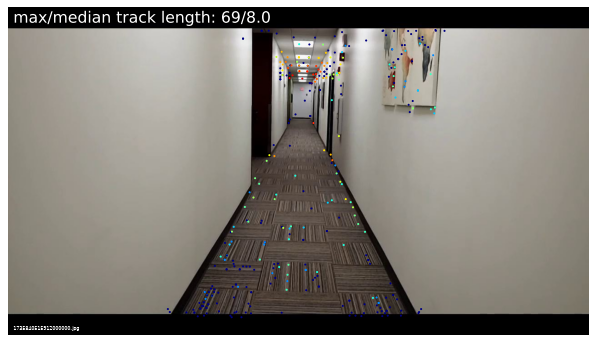

In [17]:
visualization.visualize_sfm_2d(reconstruction, images, n=1, color_by="track_length")

Color the keypoints by visibility: blue if sucessfully triangulated, red if never matched.

## Visualizing the localization
We parse the localization logs and for each query image plot matches and inliers with a few database images.

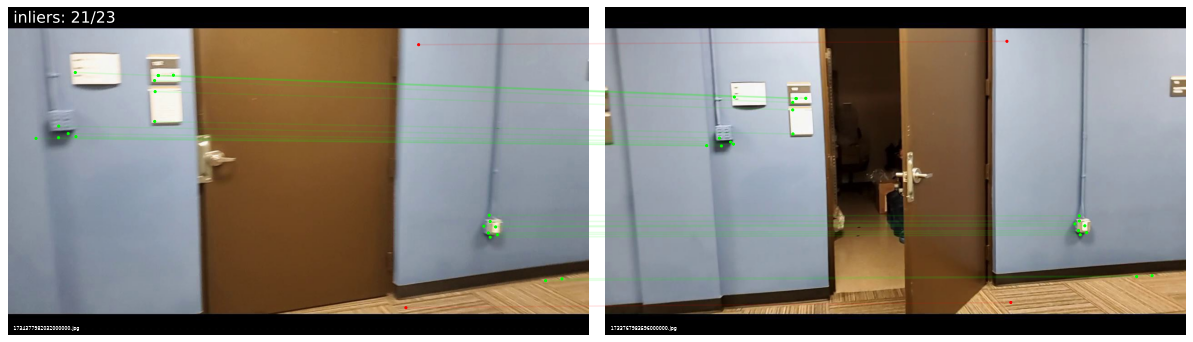

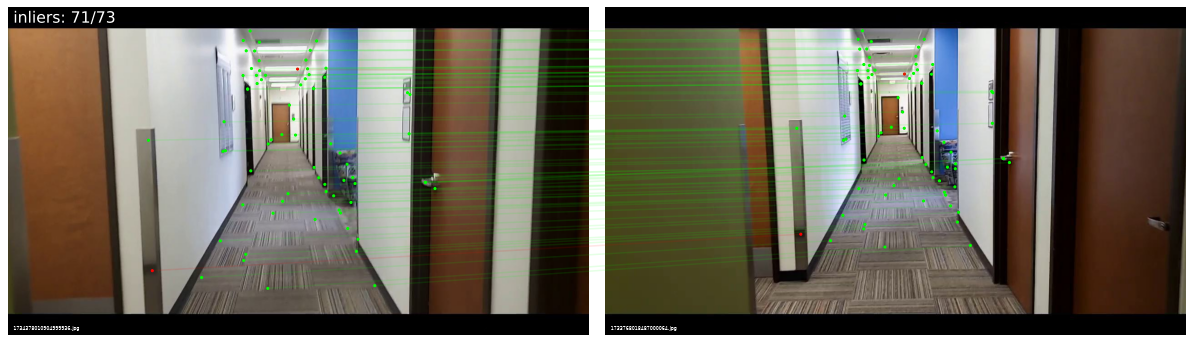

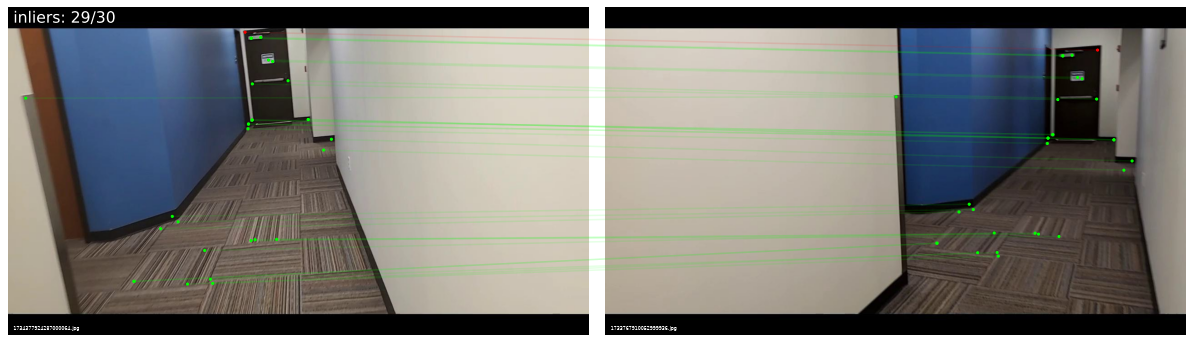

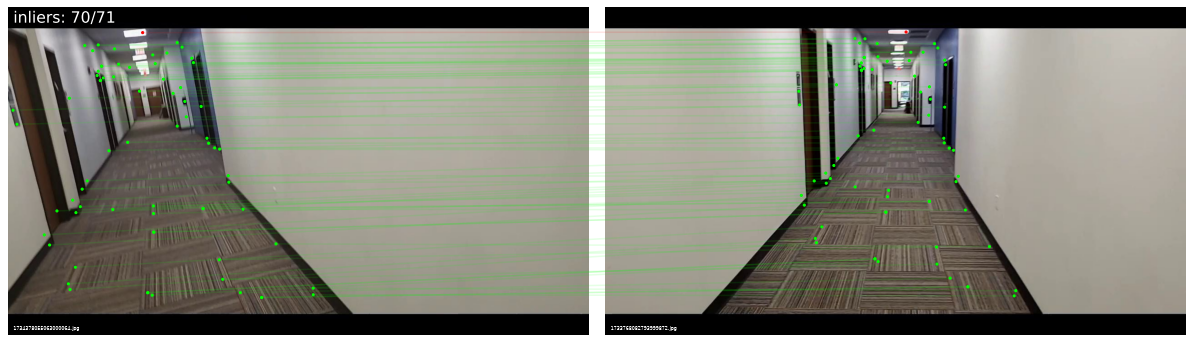

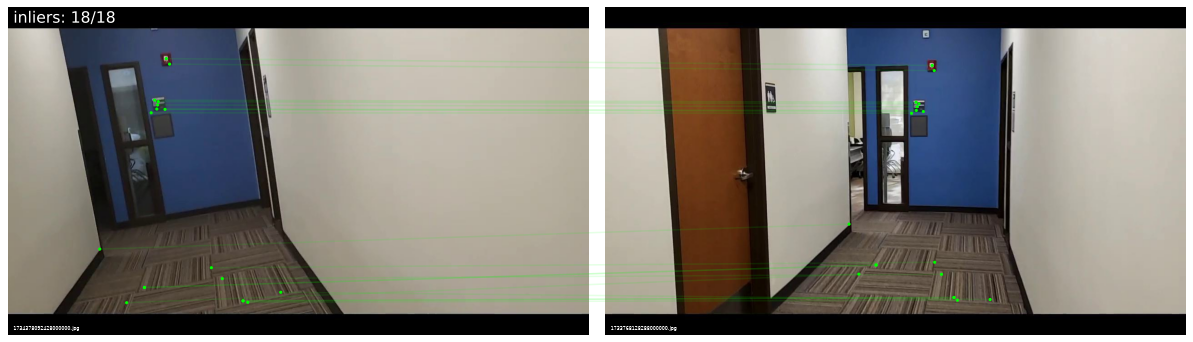

In [18]:
selected = []
visualization.visualize_loc(
    results, query_images, reconstruction, db_image_dir= images, selected = selected, n=5, top_k_db=1, prefix=None, seed=4
)

In [20]:
out_dict = read_images_text(results)
stamps, xyz, quat = colmap_dict_to_pose(out_dict)
df_pred = pd.DataFrame()
df_pred[["X", "Y", "Z"]] = xyz
df_pred["image_name"] = stamps
# stamps = stamps.reshape(-1, 1)
# final_out = np.hstack((xyz[:, 0:2], stamps))

In [21]:
gt_file = dataset / f"query_list_{query_set}_gt.txt"
df_gt = pd.read_csv(gt_file, sep=' ', header=None, names=['image_name', 'X', 'Y', 'Z'])

plot


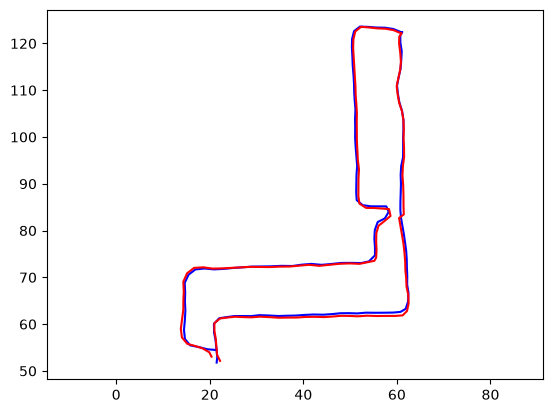

In [22]:
exclude_frames = []
# exclude_frames = ['1734377895414000128.jpg', '1734378021095000064.jpg']
df_plot = df_pred[~df_pred["image_name"].isin(exclude_frames)]
plt.plot(df_plot["X"], df_plot["Y"], color ="blue")
plt.plot(df_gt["X"], df_gt["Y"], color ="red")
plt.axis('equal')
print("plot")

In [23]:
merged_df = pd.merge(df_pred, df_gt, on='image_name', how='inner', suffixes=('_pred', '_gt'))
del_x = merged_df['X_pred'] - merged_df['X_gt']
del_y = merged_df['Y_pred'] - merged_df['Y_gt']
error = del_x**2 + del_y**2
error = np.sqrt(error)

In [24]:
error[error > 5]


Series([], dtype: float64)

In [25]:
merged_df[error > 5]

,X_pred,Y_pred,Z_pred,image_name,X_gt,Y_gt,Z_gt


In [26]:
selected = list(merged_df[error > 5]["image_name"])
print(selected)

[]


In [27]:
error.describe()

count    127.000000
mean       0.501184
std        0.259738
min        0.025769
25%        0.303122
50%        0.445928
75%        0.684237
max        1.530508
dtype: float64

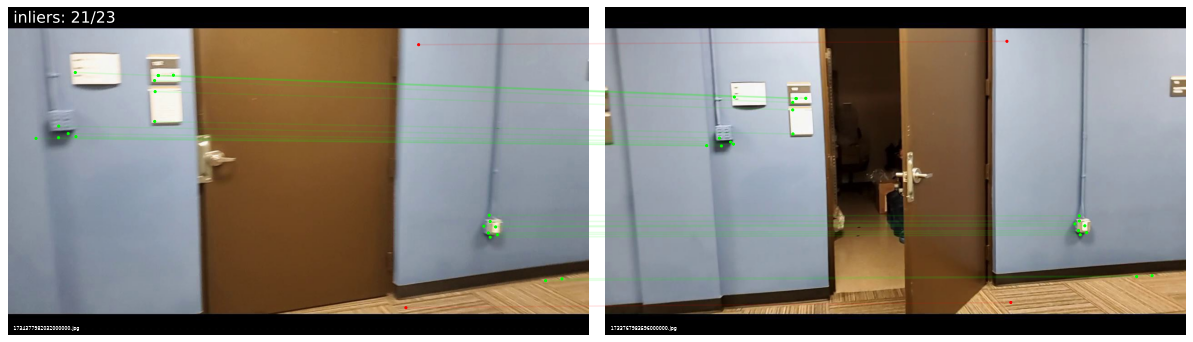

In [28]:
visualization.visualize_loc(
    results, query_images, reconstruction, db_image_dir= images, selected = selected, top_k_db=1, prefix=None, seed=4
)